# Branched Signature Kernel Model for single trajectory rough linear ODEs

## Problem Introduction

The Problem is:

$$
\begin{align*}
&k_1 u''(x)+k_2 u'(x)+k u(x)=f(x)\\
&u(0)=a\\
&u'(0)=b
\end{align*}
$$
with constants $k_1,k_2,k_2,a,$ and $b$.

The forcing in this case is a fractional Brownian Motion


## Imports

In [13]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.Linear_ODE_FBM import *
print("Using device:", device, "torch", torch.__version__)

Already up to date.
Using device: cuda torch 2.11.0+cu128


## Plotting Functions

## Problem Setup

In [14]:
# === Problem setup ===
# Interval and boundary conditions
a = 0.0       # start of x interval
b = 1      # end of x interval
ya = 0.0      # u(0)
ypa = 1.0     # u'(0)

# Operator coefficients
k1 = 1.0 #mass coeficient
k2 = 10      #dampening
k3 = 5      #stiffness

# Grid and forcing
N = 3000
x = torch.linspace(a, b, N, device=device)
hurst = .3  #Forcing Hurst Parameter

TRAIN_FRAC = 0.9  # fraction of grid points used for training



#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
x_train = x[:N_train]
x_test  = x[N_train:]

print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(x_train[0]):.3f}, {float(x_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(x_test[0]):.3f},  {float(x_test[-1]):.3f}])")


Total grid points : 3000
Train points      : 2700  (x in [0.000, 0.900])
Test  points      : 300   (x in [0.900,  1.000])


## Parameter Choices, and model hyperparameters

In [15]:
# Signature parameters
SIG_DEPTH      = 3         #Signature Depth

# Signature Normalization parameters
NORM_SCHEME = "col_robust"   # "none" or "col_zscore", "row_zscore" "row_robust", "col_robust", "row_unit", etc...
NORM_KWARGS = {}             #


#Kernel Parameters
KERNEL_TYPE = "rbf"   # or "linear"
rbf_sigma      = 1        #Rbf kernel sigma parameter, ignored if linear is chosen


#Neural Network Architecture
HIDDEN_DIMS    = (2, 4, 8, 4, 2)  #Hidden network layers: any tuple/list of ints. Ex: (512, 256, 128, 64, 32, 16)
ACTIVATION_CLS = nn.Tanh    #Activation, for example nn.Tanh, nn.ReLU, nn.GELU, custom class
extensions     = 4          #Number of path extensions to learn
num_snapshots  = 10          #number of training snapshots to visualize

#Adam Training
ADAM_ITERS     = 1500        #Adam Epochs




ADAM_LR        = 3e-4       #Adam Learning rate
ADAM_lambda_model   = 10        #ODE loss weight
ADAM_lambda_shuffle = 1e-3       #Shuffle Loss Weight


# Adam LR scheduler (ReduceLROnPlateau)
ADAM_USE_SCHEDULER = True   # or False
ADAM_SCHED_FACTOR   = 0.5   # new_lr = factor * old_lr
ADAM_SCHED_PATIENCE = 300    # epochs without improvement before LR drop


# t-lift Hölder exponent
HOLDER_VALUE = hurst  # set equal to hurst by default

retrain_stepsize = 2



## Run Solvers and Train Models

In [16]:
# === Run experiment on TRAINING data only ===
print("Running IVP and signature-kernel solvers on TRAINING split...\n")

# 1) Generate forcing on full grid, then slice to train
forcing = f_forcing_fbm(x, hurst)
forcing_train = forcing[:N_train]

print("solving ivp reference (train)")
x_ref_train, u_ref_train = solve_linear_ivp(
    x_grid=x_train,
    forcing_torch=forcing_train,
    a=float(x_train[0]), b=float(x_train[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)

# ── Method 1: Non-branched ──
print("\nsolving non-branched, method 1")
u_nb_m1, f_pred_nb_m1 = solve_signature_kernel_non_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 1: t-lift ──
print("solving t-lift, method 1")
u_tl_m1, f_pred_tl_m1 = solve_signature_kernel_tlift_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma, holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: Non-branched ──
print("\nsolving non-branched, method 2")
u_nb_m2, f_pred_nb_m2 = solve_signature_kernel_non_branched_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: t-lift ──
print("solving t-lift, method 2")
u_tl_m2, f_pred_tl_m2 = solve_signature_kernel_tlift_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma, holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 1: Branched ──
print("\nRunning Branched Solver, method 1")
u_sig_m1, snapshots_m1, f_pred_sig_m1, path_ext_m1 = solve_signature_kernel_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, adam_iters=ADAM_ITERS, adam_lr=ADAM_LR,
    ADAM_lambda_model=ADAM_lambda_model, ADAM_lambda_shuffle=ADAM_lambda_shuffle,
    extensions=extensions, rbf_sigma=rbf_sigma, snapshot_count=num_snapshots,
    hidden_dims=HIDDEN_DIMS, activation_cls=ACTIVATION_CLS,
    adam_use_scheduler=ADAM_USE_SCHEDULER, adam_sched_factor=ADAM_SCHED_FACTOR,
    adam_sched_patience=ADAM_SCHED_PATIENCE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: Branched ──
print("\nRunning Branched Solver, method 2")
u_sig_m2, snapshots_m2, f_pred_sig_m2, path_ext_m2 = solve_signature_kernel_branched_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, adam_iters=ADAM_ITERS, adam_lr=ADAM_LR,
    ADAM_lambda_model=ADAM_lambda_model, ADAM_lambda_shuffle=ADAM_lambda_shuffle,
    extensions=extensions, rbf_sigma=rbf_sigma, snapshot_count=num_snapshots,
    hidden_dims=HIDDEN_DIMS, activation_cls=ACTIVATION_CLS,
    adam_use_scheduler=ADAM_USE_SCHEDULER, adam_sched_factor=ADAM_SCHED_FACTOR,
    adam_sched_patience=ADAM_SCHED_PATIENCE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

Running IVP and signature-kernel solvers on TRAINING split...

solving ivp reference (train)



solving non-branched, method 1
method 1, non-branched model forcing match loss: 4.100e-03
solving t-lift, method 1
method 1, t-lift model forcing match loss: 4.001e-05

solving non-branched, method 2
method 2, non-branched integrated-target loss: 5.565e-07
solving t-lift, method 2
method 2, t-lift integrated-target loss: 3.210e-09

Running Branched Solver, method 1
[Adam 0050] loss=5.062e-02, PDE=6.357e-07, shuffle=5.061e+01
[Adam 0100] loss=1.917e-02, PDE=5.295e-07, shuffle=1.916e+01
[Adam 0150] loss=9.865e-03, PDE=4.531e-07, shuffle=9.861e+00
[Adam 0200] loss=5.935e-03, PDE=4.181e-07, shuffle=5.931e+00
[Adam 0250] loss=3.933e-03, PDE=3.854e-07, shuffle=3.930e+00
[Adam 0300] loss=2.786e-03, PDE=3.561e-07, shuffle=2.782e+00
[Adam 0350] loss=2.071e-03, PDE=3.299e-07, shuffle=2.067e+00
[Adam 0400] loss=1.597e-03, PDE=3.052e-07, shuffle=1.594e+00
[Adam 0450] loss=1.268e-03, PDE=2.870e-07, shuffle=1.266e+00
[Adam 0500] loss=1.031e-03, PDE=2.571e-07, shuffle=1.029e+00
[Adam 0550] loss=8.54

## Compare Model Metrics and Plot Results

In [17]:
# === Compare and Plot Results (Training Split) ===

# Compute the true Method 2 target on the training grid
rhs_m2_train = rhs_method2(forcing_train, x_train, ya, ypa, k1, k2)

print("\nComparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2")

print("\n--- Method 1 ---")
print_variant_errors("Non-branched", u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train, x_train)
print_variant_errors("t-lift      ", u_tl_m1,  f_pred_tl_m1,  u_ref_train, forcing_train, x_train)
print_variant_errors("Branched    ", u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train, x_train)

print("\n--- Method 2 ---")
print_variant_errors("Non-branched", u_nb_m2,  f_pred_nb_m2,  u_ref_train, rhs_m2_train, x_train)
print_variant_errors("t-lift      ", u_tl_m2,  f_pred_tl_m2,  u_ref_train, rhs_m2_train, x_train)
print_variant_errors("Branched    ", u_sig_m2, f_pred_sig_m2, u_ref_train, rhs_m2_train, x_train)

# ── Method 1: % improvement vs non-branched baseline ──
nb_m1  = get_errors(u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train)
tl_m1  = get_errors(u_tl_m1,  f_pred_tl_m1,  u_ref_train, forcing_train)
sig_m1 = get_errors(u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train)

print("\n--- Method 1: % improvement vs Non-branched (positive = better) ---")
print(f"  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m1,  nb_m1)
print_pct_improvement("Branched    ", sig_m1, nb_m1)

# ── Method 2: % improvement vs non-branched baseline ──
nb_m2  = get_errors(u_nb_m2,  f_pred_nb_m2,  u_ref_train, rhs_m2_train)
tl_m2  = get_errors(u_tl_m2,  f_pred_tl_m2,  u_ref_train, rhs_m2_train)
sig_m2 = get_errors(u_sig_m2, f_pred_sig_m2, u_ref_train, rhs_m2_train)

print("\n--- Method 2: % improvement vs Non-branched (positive = better) ---")
print(f"  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m2,  nb_m2)
print_pct_improvement("Branched    ", sig_m2, nb_m2)

# ── Method 1 vs Method 2: % improvement in solution fit per variant ──
print("\n--- Method 1 vs Method 2: % solution improvement (positive = Method 1 better) ---")

for label, e_m1, e_m2 in [
    ("Non-branched", nb_m1,  nb_m2),
    ("t-lift      ", tl_m1,  tl_m2),
    ("Branched    ", sig_m1, sig_m2),
]:
    def pct(m1_val, m2_val): return 100.0 * (m2_val - m1_val) / (abs(m2_val) + 1e-12)
    print(f"  [{label}]"
          f"  MSE(u)={pct(e_m1['mse_u'], e_m2['mse_u']):+.1f}%"
          f"  Rel(u)={pct(e_m1['rel_u'], e_m2['rel_u']):+.1f}%")


Comparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2

--- Method 1 ---
  [Non-branched]  MSE(u)=5.983e-12  RelMSE(u)=7.472e-10  MSE(f)=4.100e-03  RelMSE(f)=1.162e-02
  [t-lift      ]  MSE(u)=1.542e-13  RelMSE(u)=1.925e-11  MSE(f)=4.001e-05  RelMSE(f)=1.134e-04
  [Branched    ]  MSE(u)=8.174e-13  RelMSE(u)=1.021e-10  MSE(f)=1.048e-07  RelMSE(f)=2.969e-07

--- Method 2 ---
  [Non-branched]  MSE(u)=5.562e-07  RelMSE(u)=6.946e-05  MSE(f)=5.565e-07  RelMSE(f)=1.685e-06
  [t-lift      ]  MSE(u)=3.210e-09  RelMSE(u)=4.009e-07  MSE(f)=3.210e-09  RelMSE(f)=9.718e-09
  [Branched    ]  MSE(u)=5.264e-11  RelMSE(u)=6.574e-09  MSE(f)=5.190e-11  RelMSE(f)=1.571e-10

--- Method 1: % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [t-lift      ]  MSE(u)=+83.5%  RelMSE(u)=+97.3%  MSE(f)=+99.0%  RelMSE(f)=+99.0%
  [Branched    ]  MSE(u)=+74.0%  RelMSE(u)=+86.2%  MSE(f)=+100.0%  RelMSE(f)=+100.0%

--- Method 2: % improvement vs Non-branched (pos

## Plotting for Calibration

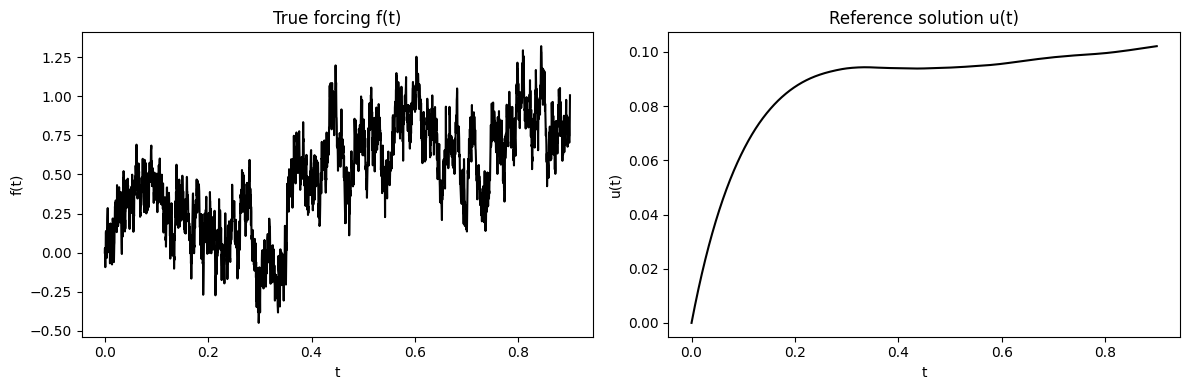

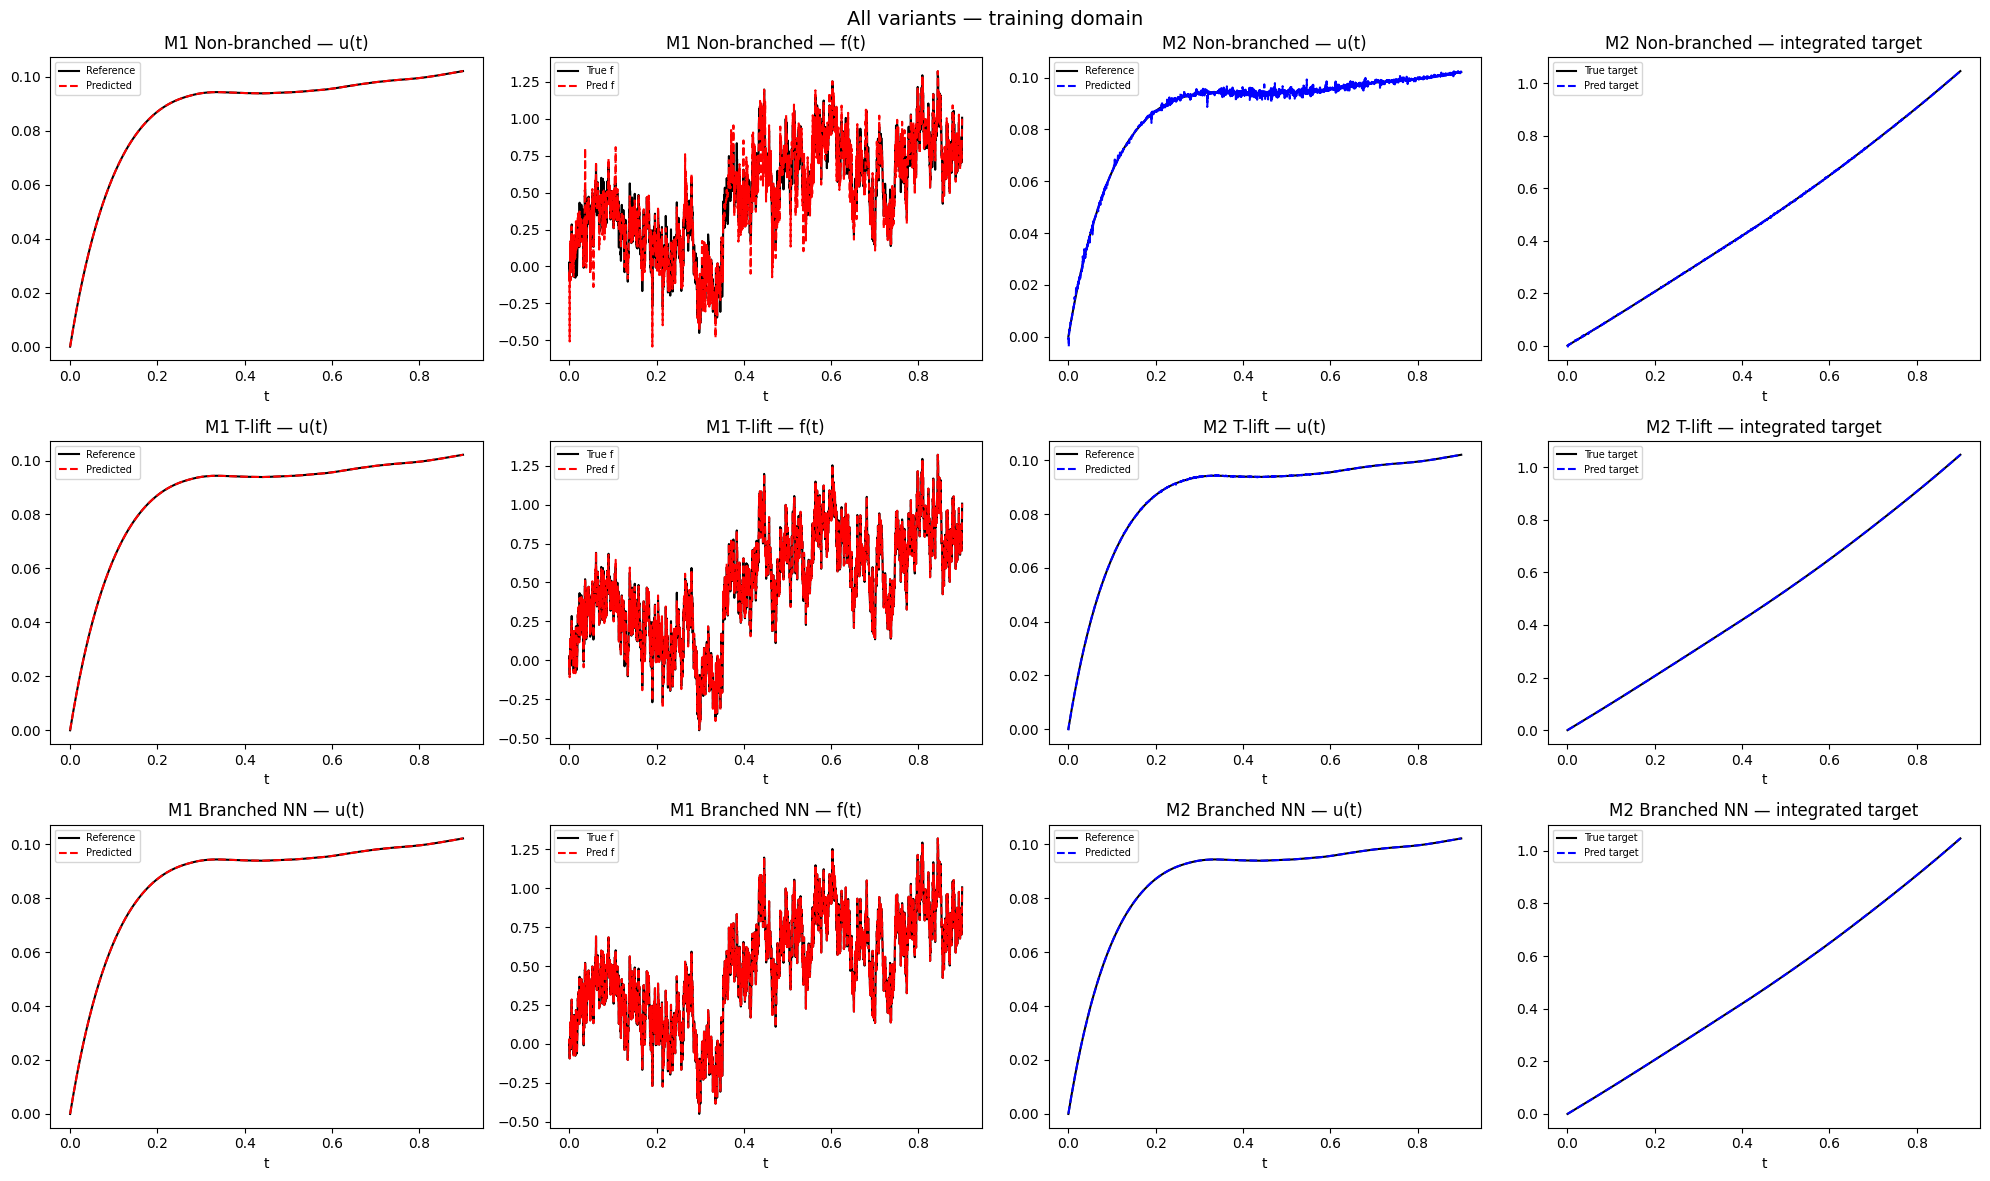

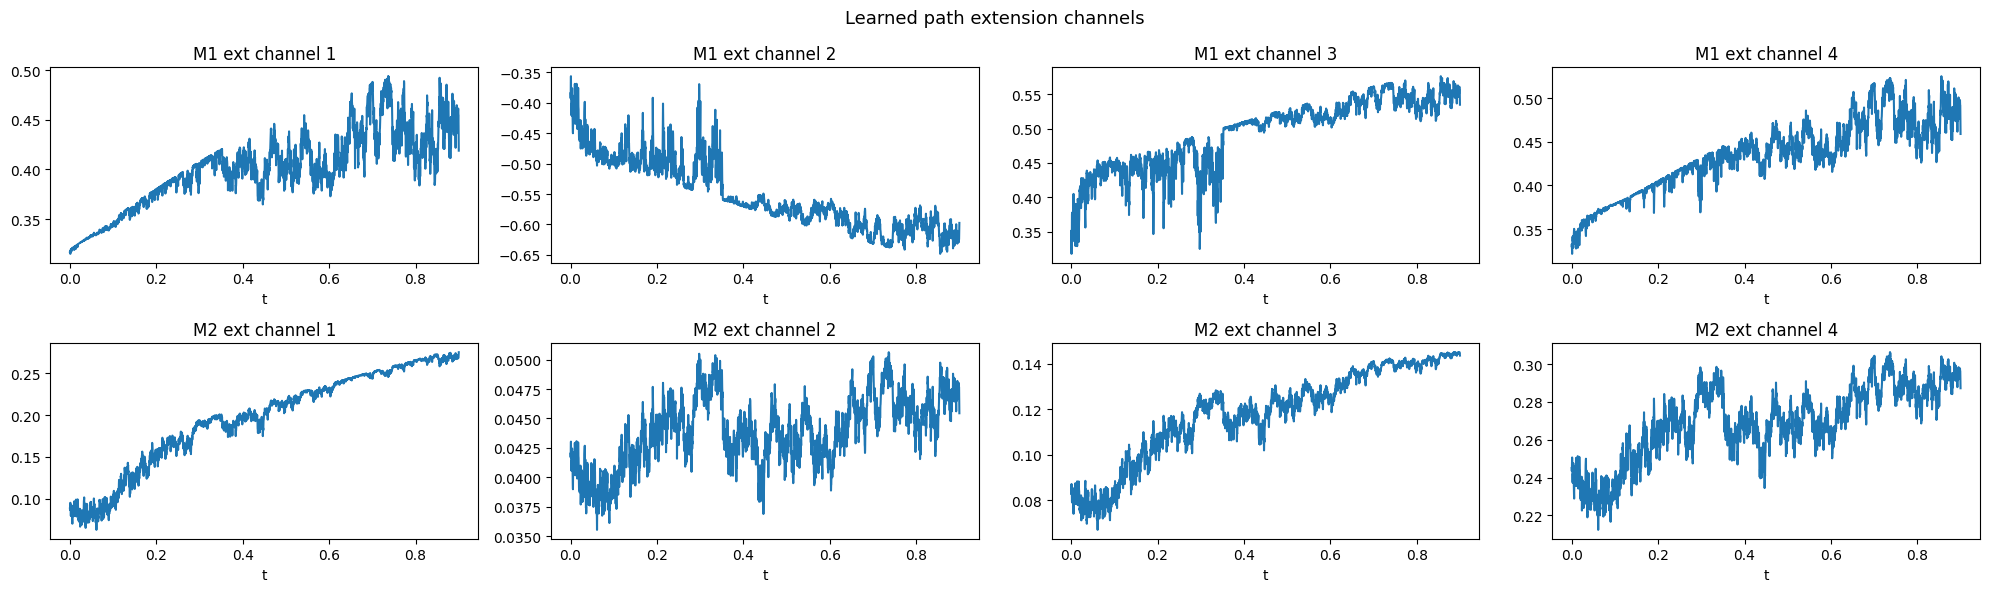

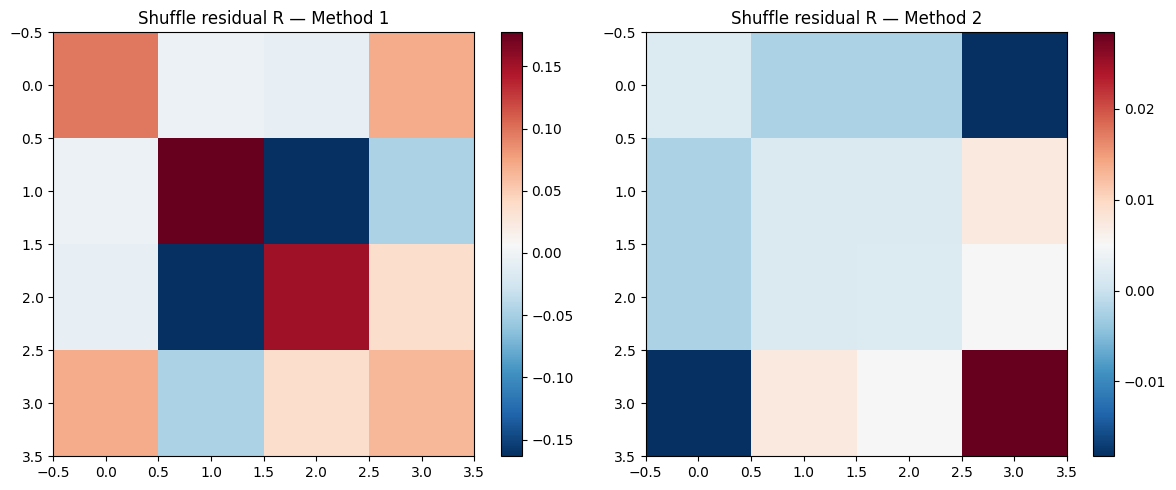

In [18]:
plot_reference_forcing_and_solution(
    x=x_train, f_true=forcing_train, u_ref=u_ref_train
)

# ── Unified comparison plot: all variants × both methods ──
rhs_nb_m2  = rhs_method2(forcing_train, x_train, ya, ypa, k1, k2)
rhs_tl_m2  = rhs_nb_m2   # same true target for all method 2 variants
rhs_sig_m2 = rhs_nb_m2

plot_all_variants_comparison(
    x=x_train, f_true=forcing_train, u_ref=u_ref_train,
    f_pred_nb_m1=f_pred_nb_m1,   u_nb_m1=u_nb_m1,
    f_pred_tl_m1=f_pred_tl_m1,   u_tl_m1=u_tl_m1,
    f_pred_sig_m1=f_pred_sig_m1, u_sig_m1=u_sig_m1,
    f_pred_nb_m2=f_pred_nb_m2,   u_nb_m2=u_nb_m2,
    f_pred_tl_m2=f_pred_tl_m2,   u_tl_m2=u_tl_m2,
    f_pred_sig_m2=f_pred_sig_m2, u_sig_m2=u_sig_m2,
    f_target_nb_m2=rhs_nb_m2,
    f_target_tl_m2=rhs_tl_m2,
    f_target_sig_m2=rhs_sig_m2,
)

# ── Unified extensions plot ──
plot_all_extensions(
    x=x_train, f_true=forcing_train,
    path_ext_m1=path_ext_m1,
    path_ext_m2=path_ext_m2,
)

# ── Unified shuffle residual matrix plot ──
plot_all_shuffle_matrices(
    x=x_train, f_true=forcing_train,
    path_ext_m1=path_ext_m1,
    path_ext_m2=path_ext_m2,
)

# Testing with retrain

In [19]:
print("\nRunning TESTING routines on train/test split...\n")

forcing_test = forcing[N_train:]

# ── Test: Non-branched, method 1 ──
print("testing non-branched, method 1")
u_test_nb_m1, f_test_pred_nb_m1 = test_nonbranched_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)

# ── Test: t-lift, method 1 ──
print("testing t-lift, method 1")
u_test_tl_m1, f_test_pred_tl_m1 = test_branched_tlift_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)

# ── Test: learned branched NN, method 1 ──
print("testing branched NN, method 1")
u_test_sig_m1, f_test_pred_sig_m1 = test_branched_NN_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    pathextension=path_ext_m1,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)

# ── Test: Non-branched, method 2 ──
print("testing non-branched, method 2")
u_test_nb_m2, f_test_pred_nb_m2 = test_nonbranched_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)

# ── Test: t-lift, method 2 ──
print("testing t-lift, method 2")
u_test_tl_m2, f_test_pred_tl_m2 = test_branched_tlift_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)

# ── Test: learned branched NN, method 2 ──
print("testing branched NN, method 2")
u_test_sig_m2, f_test_pred_sig_m2 = test_branched_NN_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    pathextension=path_ext_m2,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=retrain_stepsize,
)


Running TESTING routines on train/test split...

testing non-branched, method 1
final forcing loss (train+test, last beta): 1.069e-02
testing t-lift, method 1
final forcing loss (train+test, last beta): 3.904e-04
testing branched NN, method 1
final forcing loss (train+test, last beta): 6.284e-04
testing non-branched, method 2
final forcing loss (train+test, last beta): 7.129e-02
testing t-lift, method 2
final forcing loss (train+test, last beta): 7.127e-02
testing branched NN, method 2
final forcing loss (train+test, last beta): 7.080e-02


In [20]:
# === Full-grid reference solution ===
print("\nsolving ivp reference (full grid)")
x_ref_full, u_ref_full = solve_linear_ivp(
    x_grid=x,
    forcing_torch=forcing,
    a=float(x[0]), b=float(x[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)

# === Assemble full-path tensors + Method 2 targets ===
R = assemble_full_path_results(
    N_train,
    x, x_test, forcing,
    u_nb_m1,  f_pred_nb_m1,  u_test_nb_m1,  f_test_pred_nb_m1,
    u_tl_m1,  f_pred_tl_m1,  u_test_tl_m1,  f_test_pred_tl_m1,
    u_sig_m1, f_pred_sig_m1, u_test_sig_m1, f_test_pred_sig_m1,
    u_nb_m2,  f_pred_nb_m2,  u_test_nb_m2,  f_test_pred_nb_m2,
    u_tl_m2,  f_pred_tl_m2,  u_test_tl_m2,  f_test_pred_tl_m2,
    u_sig_m2, f_pred_sig_m2, u_test_sig_m2, f_test_pred_sig_m2,
    ya, ypa, k1, k2,
)
u_nb_m1_full, f_pred_nb_m1_full   = R["u_nb_m1"],  R["f_pred_nb_m1"]
u_tl_m1_full, f_pred_tl_m1_full   = R["u_tl_m1"],  R["f_pred_tl_m1"]
u_sig_m1_full, f_pred_sig_m1_full = R["u_sig_m1"], R["f_pred_sig_m1"]
u_nb_m2_full, f_pred_nb_m2_full   = R["u_nb_m2"],  R["f_pred_nb_m2"]
u_tl_m2_full, f_pred_tl_m2_full   = R["u_tl_m2"],  R["f_pred_tl_m2"]
u_sig_m2_full, f_pred_sig_m2_full = R["u_sig_m2"], R["f_pred_sig_m2"]
rhs_true_m2_full = R["rhs_m2_full"]
rhs_true_m2_test = R["rhs_m2_test"]


# === FULL path errors (train + test) ===
full_errs = print_all_errors(
    "FULL (train+test)",
    x,       u_ref_full,         forcing,
    R["u_nb_m1"],  R["f_pred_nb_m1"],
    R["u_tl_m1"],  R["f_pred_tl_m1"],
    R["u_sig_m1"], R["f_pred_sig_m1"],
    R["u_nb_m2"],  R["f_pred_nb_m2"],
    R["u_tl_m2"],  R["f_pred_tl_m2"],
    R["u_sig_m2"], R["f_pred_sig_m2"],
    R["rhs_m2_full"],
)

# === TEST-only errors ===
test_errs = print_all_errors(
    "TEST ONLY",
    x_test,  u_ref_full[N_train:],  forcing[N_train:],
    R["u_nb_m1"][N_train:],  R["f_pred_nb_m1"][N_train:],
    R["u_tl_m1"][N_train:],  R["f_pred_tl_m1"][N_train:],
    R["u_sig_m1"][N_train:], R["f_pred_sig_m1"][N_train:],
    R["u_nb_m2"][N_train:],  R["f_pred_nb_m2"][N_train:],
    R["u_tl_m2"][N_train:],  R["f_pred_tl_m2"][N_train:],
    R["u_sig_m2"][N_train:], R["f_pred_sig_m2"][N_train:],
    R["rhs_m2_test"],
)


solving ivp reference (full grid)

Comparing ALL variants on FULL (train+test): non-branched, t-lift, branched | method 1 vs method 2

--- Method 1 (FULL (train+test)) ---
  [Non-branched]  MSE(u)=5.871e-12  RelMSE(u)=7.093e-10  MSE(f)=1.069e-02  RelMSE(f)=2.572e-02
  [t-lift      ]  MSE(u)=2.298e-12  RelMSE(u)=2.777e-10  MSE(f)=3.904e-04  RelMSE(f)=9.395e-04
  [Branched    ]  MSE(u)=8.137e-13  RelMSE(u)=9.831e-11  MSE(f)=6.284e-04  RelMSE(f)=1.512e-03

--- Method 2 (FULL (train+test)) ---
  [Non-branched]  MSE(u)=4.852e-06  RelMSE(u)=5.862e-04  MSE(f)=4.867e-06  RelMSE(f)=1.151e-05
  [t-lift      ]  MSE(u)=5.654e-06  RelMSE(u)=6.830e-04  MSE(f)=5.672e-06  RelMSE(f)=1.341e-05
  [Branched    ]  MSE(u)=6.686e-05  RelMSE(u)=8.078e-03  MSE(f)=6.708e-05  RelMSE(f)=1.586e-04

--- Method 1 (FULL (train+test)): % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [t-lift      ]  MSE(u)=+52.0%  RelMSE(u)=+60.8%  MSE(f)=+96.3%  RelMSE(f)=+96.3%
  [Branched    ]  

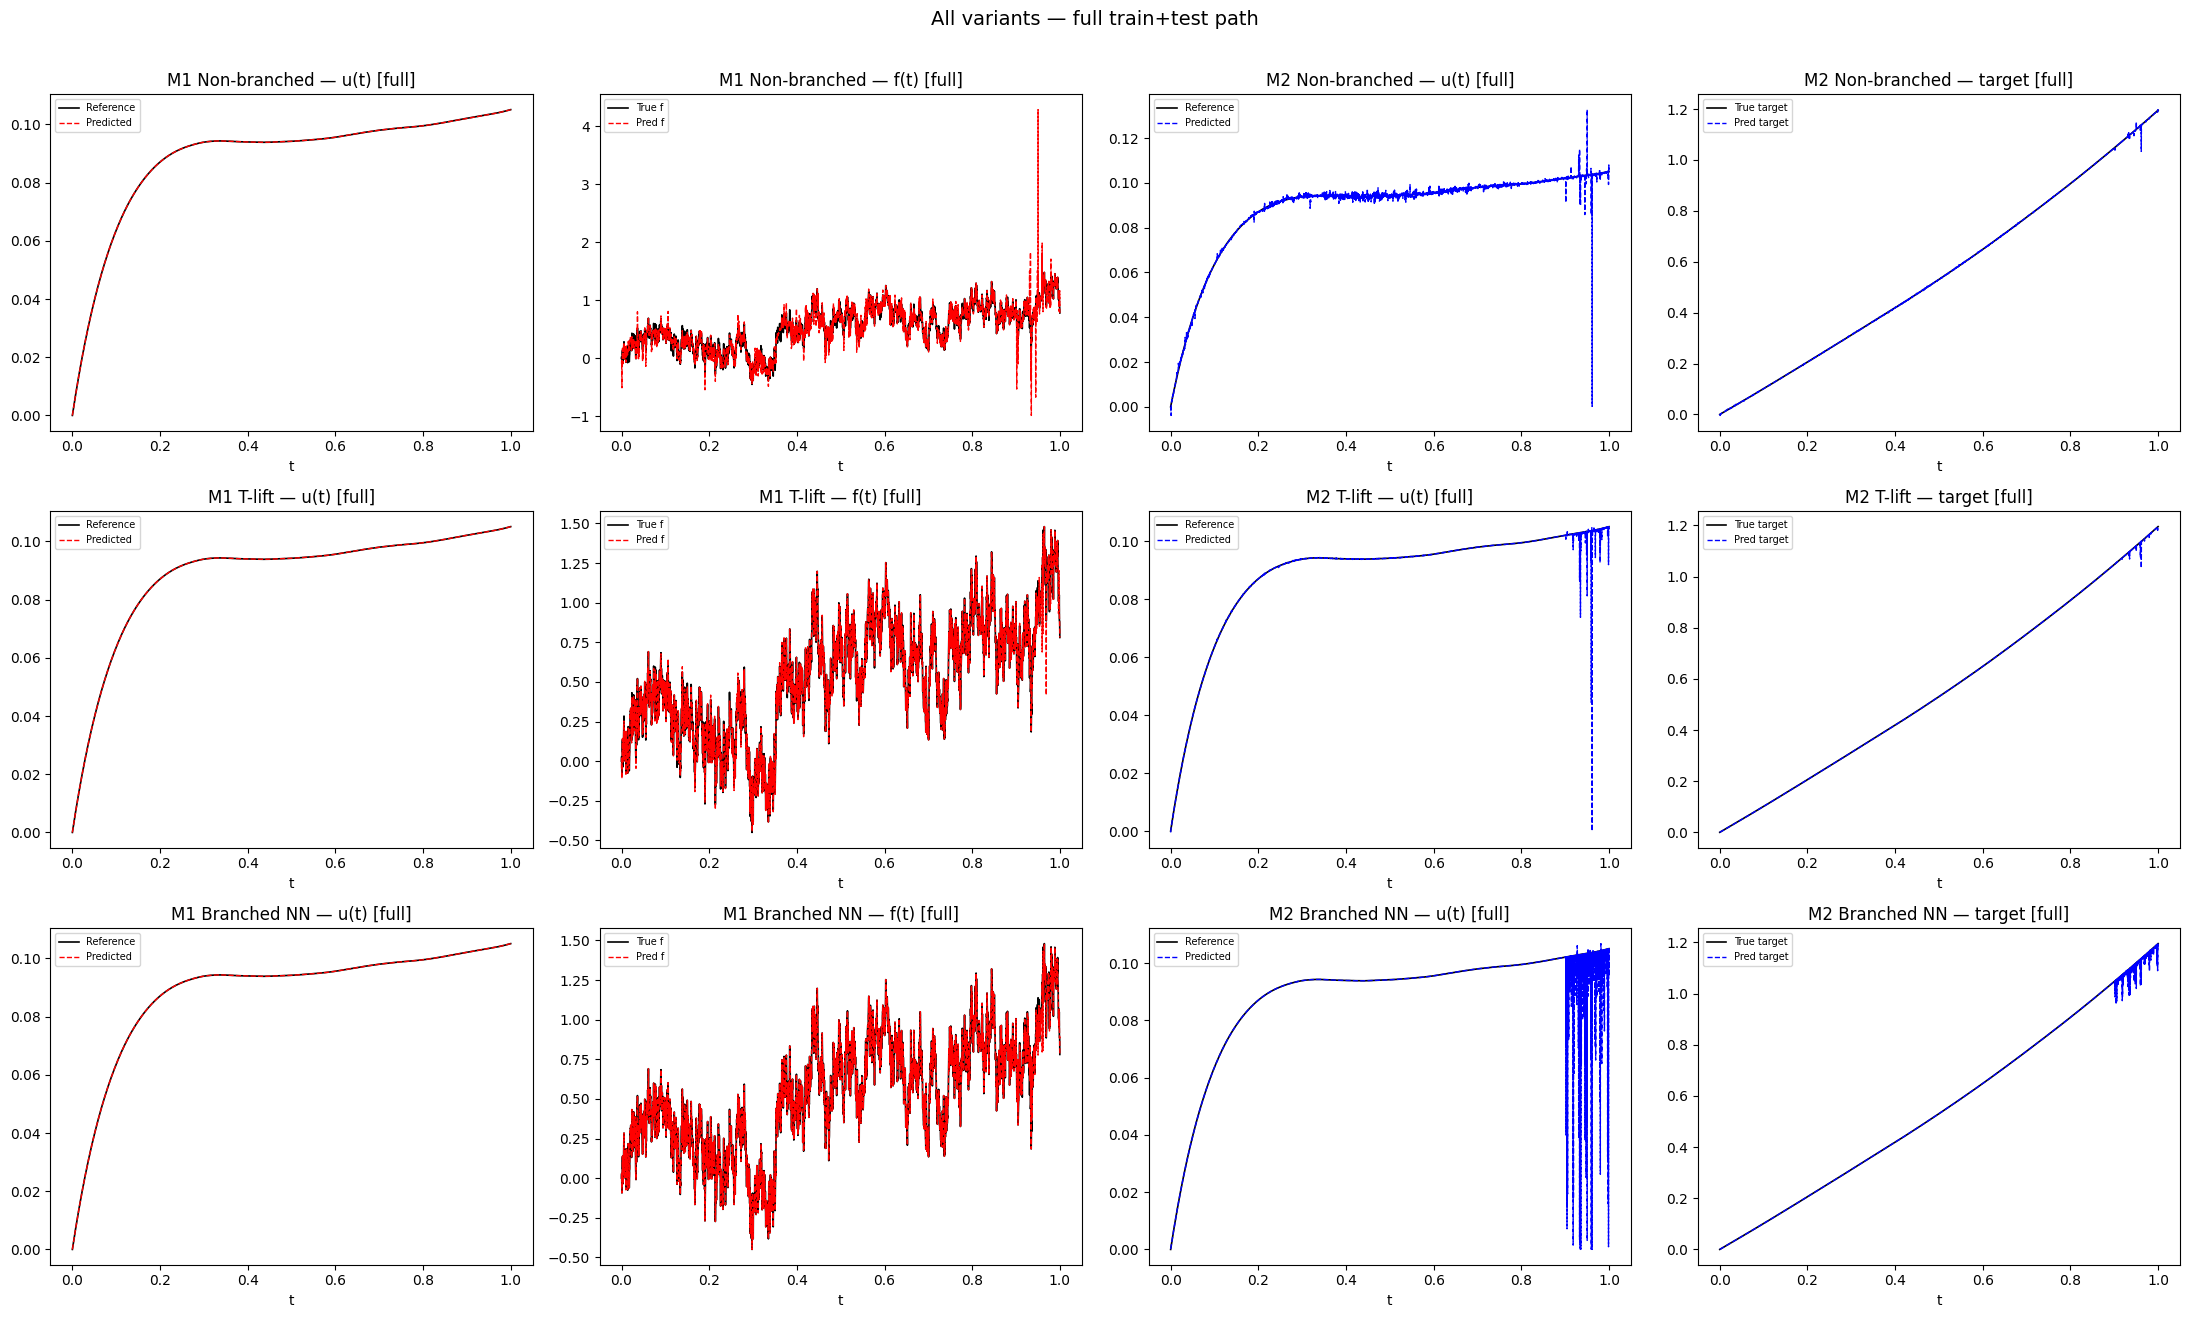

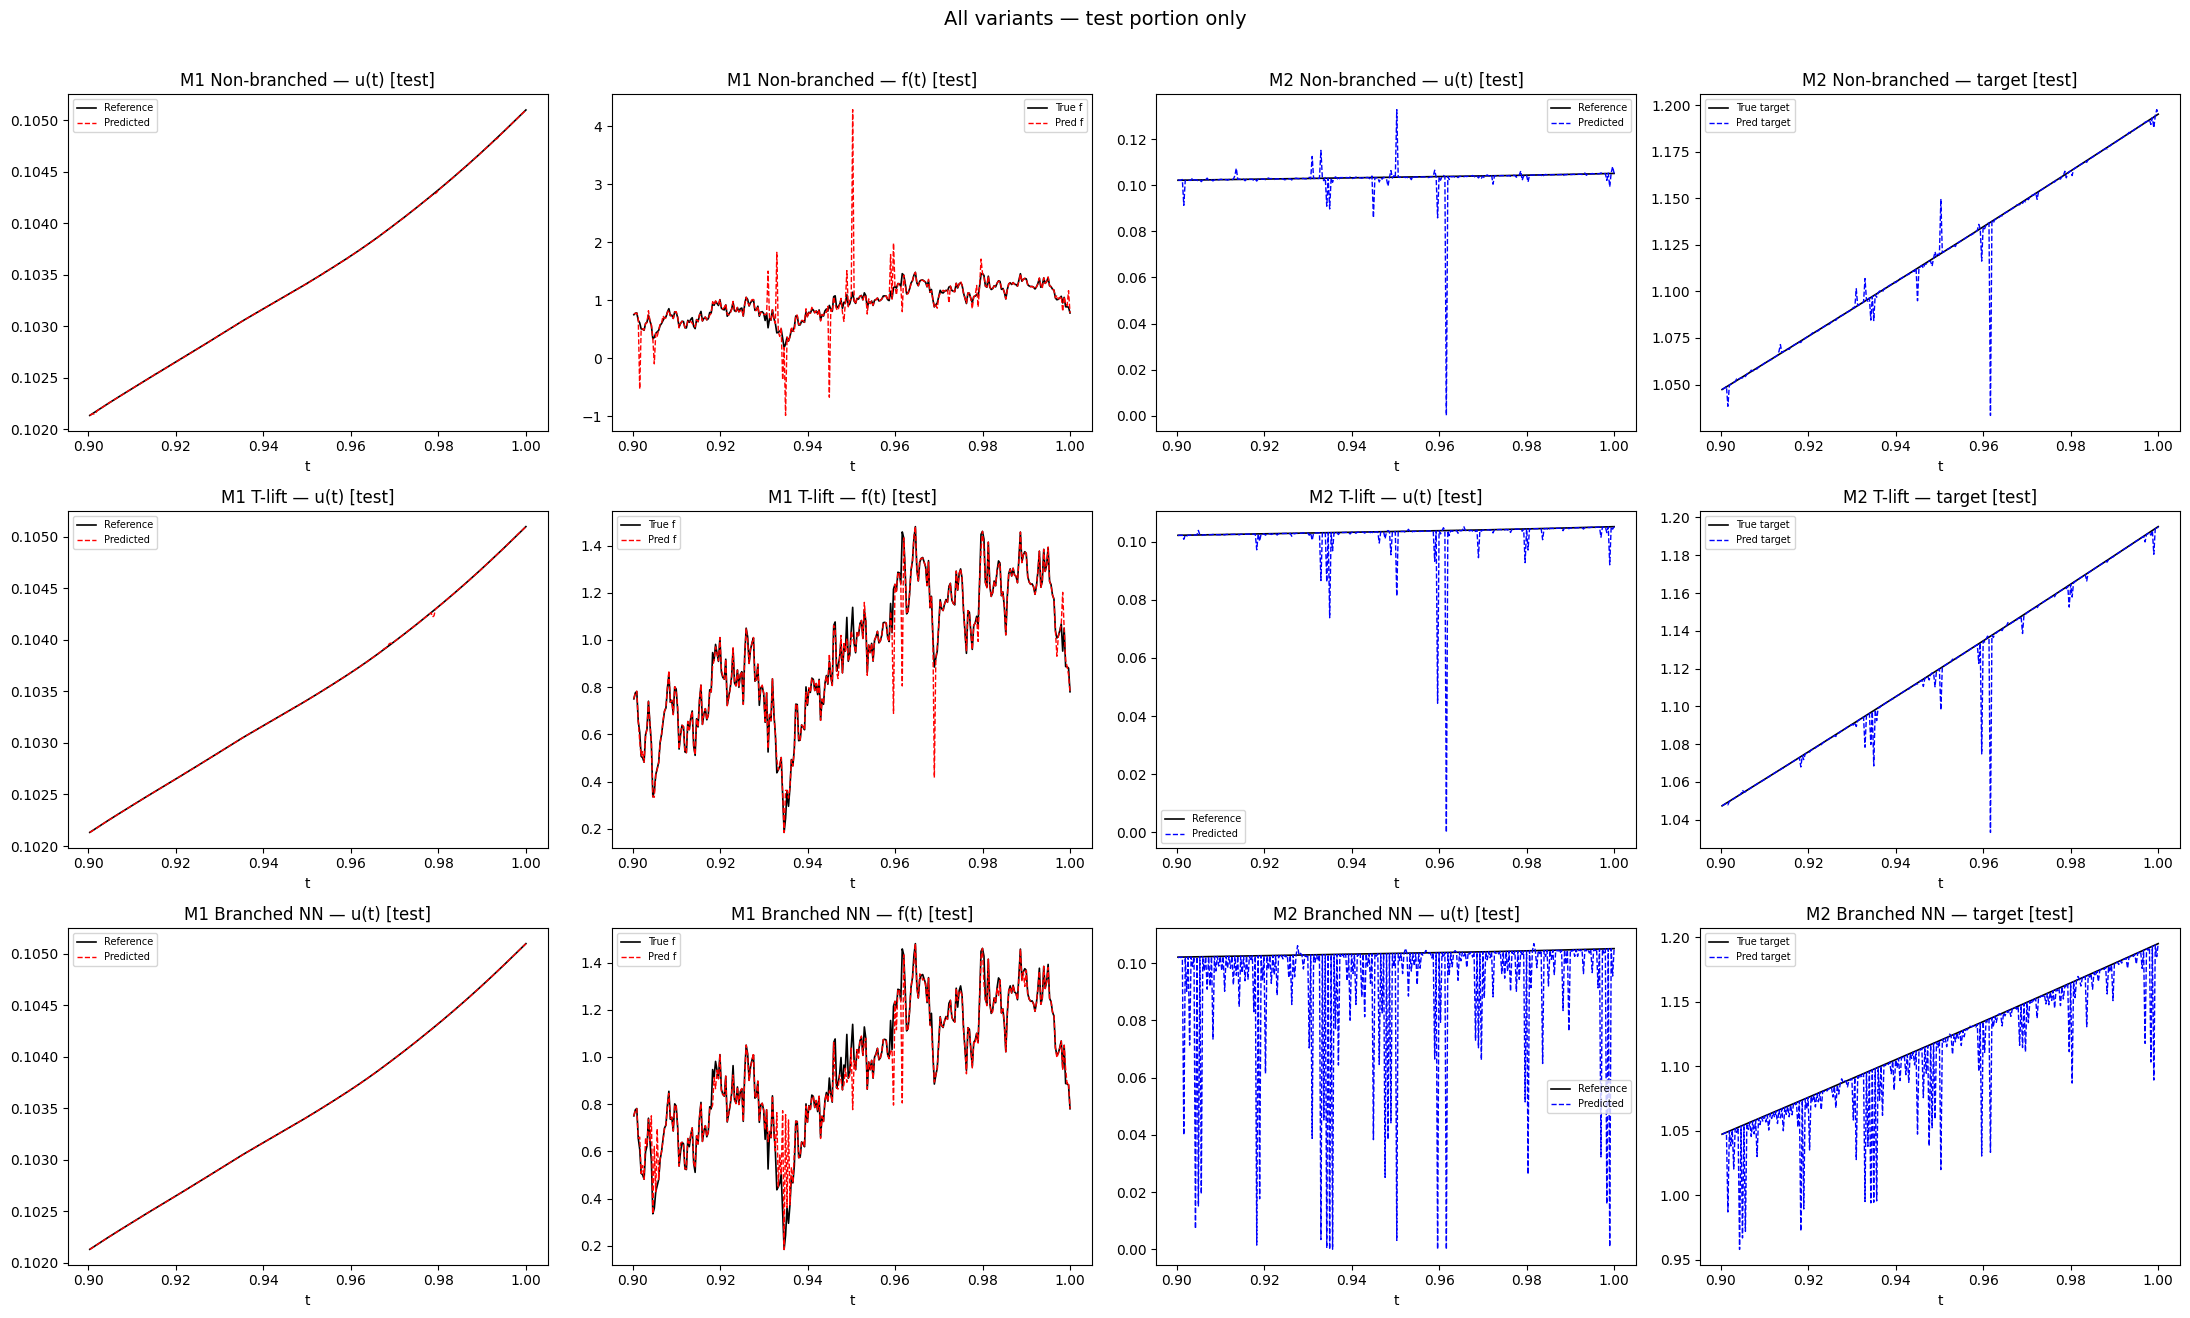

In [21]:
# === Plots: FULL train+test and TEST only ===

# 1) Full path: all variants, Method 1 & 2
plot_all_variants_full_train_test(
    x_full=x,
    f_true_full=forcing,
    u_ref_full=u_ref_full,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_tl_m1_full=u_tl_m1_full,
    f_pred_tl_m1_full=f_pred_tl_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    u_nb_m2_full=u_nb_m2_full,
    f_pred_nb_m2_full=f_pred_nb_m2_full,
    u_tl_m2_full=u_tl_m2_full,
    f_pred_tl_m2_full=f_pred_tl_m2_full,
    u_sig_m2_full=u_sig_m2_full,
    f_pred_sig_m2_full=f_pred_sig_m2_full,
    f_target_nb_m2_full=rhs_true_m2_full,
    f_target_tl_m2_full=rhs_true_m2_full,
    f_target_sig_m2_full=rhs_true_m2_full,
)

# 2) Test portion only: all variants, Method 1 & 2
plot_all_variants_test_only(
    x_test=x_test,
    u_ref_full=u_ref_full,
    f_true_full=forcing,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_tl_m1_full=u_tl_m1_full,
    f_pred_tl_m1_full=f_pred_tl_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    u_nb_m2_full=u_nb_m2_full,
    f_pred_nb_m2_full=f_pred_nb_m2_full,
    u_tl_m2_full=u_tl_m2_full,
    f_pred_tl_m2_full=f_pred_tl_m2_full,
    u_sig_m2_full=u_sig_m2_full,
    f_pred_sig_m2_full=f_pred_sig_m2_full,
    N_train=N_train,
    f_target_nb_m2_full=rhs_true_m2_full,
    f_target_tl_m2_full=rhs_true_m2_full,
    f_target_sig_m2_full=rhs_true_m2_full,
)

In [22]:
# ── SELECTION ────────────────────────────────────────────────────────────────
METRIC = "RelMSE"   # <--- change to "MSE" or "RelMSE"

# ── metric selection ─────────────────────────────────────────────────────────
if METRIC == "MSE":
    u_col, f_col, label = "mse_u", "mse_f", "MSE"
else:
    u_col, f_col, label = "rel_u", "rel_f", "Rel-MSE"

methods  = ["Method 1", "Method 2"]
variants = ["Non-branched", "T-lift", "Branched"]

_key_map = {
    ("Method 1", "Non-branched"): "nb_m1",
    ("Method 1", "T-lift"):       "tl_m1",
    ("Method 1", "Branched"):     "sig_m1",
    ("Method 2", "Non-branched"): "nb_m2",
    ("Method 2", "T-lift"):       "tl_m2",
    ("Method 2", "Branched"):     "sig_m2",
}

def val(errs_dict, method, variant, col):
    e = errs_dict.get(_key_map[(method, variant)], {})
    return float(e.get(col, float("nan")))

import pandas as pd
from IPython.display import display, HTML

BASE_STYLES = [
    {"selector": "caption",
     "props": [("font-size", "14px"), ("font-weight", "bold"),
               ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th",
     "props": [("font-size", "12px"), ("text-align", "center"),
               ("padding", "6px 12px"), ("border-bottom", "2px solid #000"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "td",
     "props": [("text-align", "right"), ("font-family", "monospace"),
               ("font-size", "12px"), ("padding", "5px 12px"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "tr",
     "props": [("background-color", "white"), ("color", "black")]},
    {"selector": "",
     "props": [("border", "1px solid #ccc"), ("background-color", "white")]},
]

def show(df, caption):
    display(HTML(f"<br><b style='font-size:13px; color:black'>{caption}</b>"))
    display(
        df.style
          .format("{:.3e}")
          .set_table_styles(BASE_STYLES)
          .set_properties(**{"background-color": "white", "color": "black"})
    )

# ── Table 1: Method Comparison (u only) ──────────────────────────────────────
t1_data = {}
for method in methods:
    for variant in variants:
        t1_data[(method, variant)] = {
            "Train": val(full_errs, method, variant, u_col),
            "Test":  val(test_errs, method, variant, u_col),
        }

t1 = pd.DataFrame(
    {(method, variant): t1_data[(method, variant)]
     for method in methods for variant in variants}
).T
t1.index = pd.MultiIndex.from_tuples(t1.index, names=["Method", "Variant"])
show(t1, f"Method Comparison — {label}(u)")

# ── Table 2: Method 1 (u and f, Test and Train) ───────────────────────────────
t2_rows = {}
for variant in variants:
    t2_rows[variant] = {
        ("Testing",  "Forcing"):  val(test_errs,  "Method 1", variant, f_col),
        ("Testing",  "Solution"): val(test_errs,  "Method 1", variant, u_col),
        ("Training", "Forcing"):  val(full_errs,  "Method 1", variant, f_col),
        ("Training", "Solution"): val(full_errs,  "Method 1", variant, u_col),
    }

t2 = pd.DataFrame(t2_rows).T
t2.index.name = "Variant"
t2.columns = pd.MultiIndex.from_tuples(t2.columns, names=["Split", "Target"])
show(t2, f"Method 1 — {label}")

# ── Table 3: Method 2 (u and f, Test and Train) ───────────────────────────────
t3_rows = {}
for variant in variants:
    t3_rows[variant] = {
        ("Testing",  "Int. Forcing"): val(test_errs,  "Method 2", variant, f_col),
        ("Testing",  "Solution"):     val(test_errs,  "Method 2", variant, u_col),
        ("Training", "Int. Forcing"): val(full_errs,  "Method 2", variant, f_col),
        ("Training", "Solution"):     val(full_errs,  "Method 2", variant, u_col),
    }

t3 = pd.DataFrame(t3_rows).T
t3.index.name = "Variant"
t3.columns = pd.MultiIndex.from_tuples(t3.columns, names=["Split", "Target"])
show(t3, f"Method 2 — {label}")

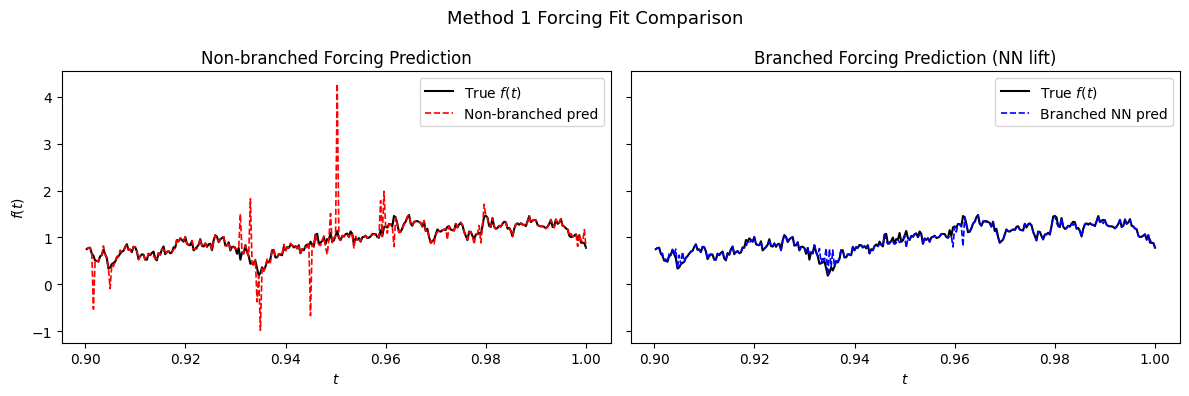

In [23]:
# ── call ─────────────────────────────────────────────────────────────────────
plot_m1_forcing_calibration_sidebyside(
    x         = x_test,
    ftrue     = forcing[N_train:],
    fpred_nb  = f_pred_nb_m1_full[N_train:],
    fpred_sig = f_pred_sig_m1_full[N_train:],
)

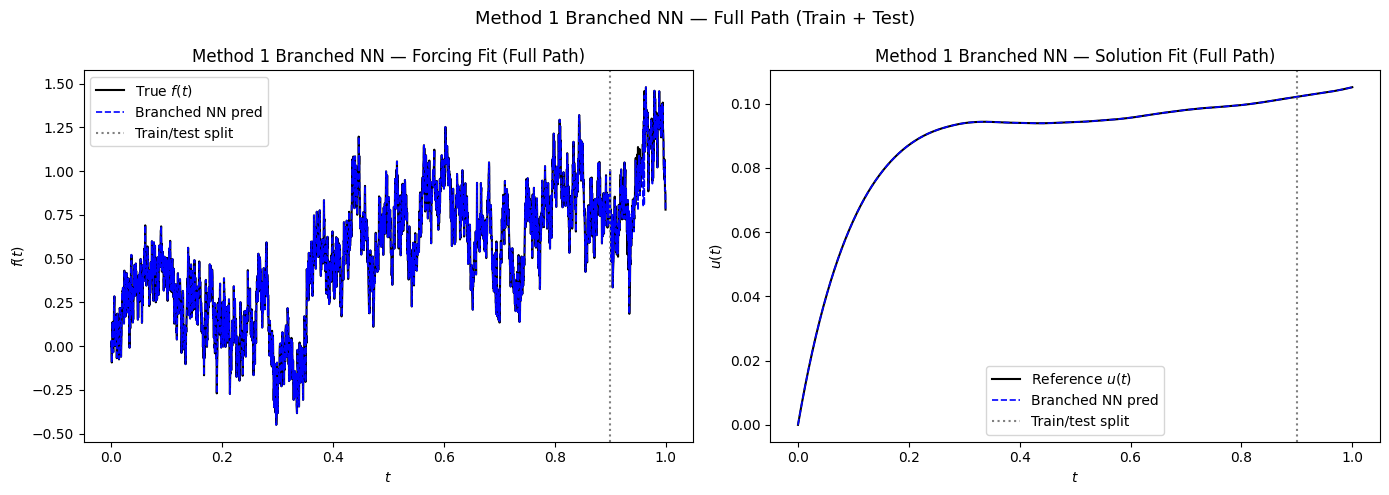

In [24]:
# ── call ─────────────────────────────────────────────────────────────────────
plot_m1_branched_full_sidebyside(
    x_full             = x,
    forcing_full       = forcing,
    u_ref_full         = u_ref_full,
    f_pred_sig_m1_full = f_pred_sig_m1_full,
    u_sig_m1_full      = u_sig_m1_full,
    N_train            = N_train,
)